In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Make results reproducible
np.random.seed(42)

# Number of transactions
n = 5000

# Generate Customer IDs
customer_ids = np.random.randint(1001, 1501, n)

# Generate order dates
order_dates = pd.date_range(
    start="2024-01-01",
    end="2025-12-31",
    periods=n
)

# Generate product categories
categories = np.random.choice(
    ["Electronics", "Clothing", "Home", "Beauty", "Sports"],
    n
)

# Generate quantity
quantity = np.random.randint(1, 6, n)

# Generate unit price
unit_price = np.round(
    np.random.uniform(100, 5000, n),
    2
)

# Calculate total amount
total_amount = np.round(
    quantity * unit_price,
    2
)

# Create DataFrame
df = pd.DataFrame({
    "Customer_ID": customer_ids,
    "Order_Date": order_dates,
    "Category": categories,
    "Quantity": quantity,
    "Unit_Price": unit_price,
    "Total_Amount": total_amount
})

# Display first 5 rows
df.head()

,Customer_ID,Order_Date,Category,Quantity,Unit_Price,Total_Amount
0,1103,2024-01-01 00:00:00.000000000,Home,4,1430.57,5722.28
1,1436,2024-01-01 03:30:16.923384676,Sports,3,2301.37,6904.11
2,1349,2024-01-01 07:00:33.846769353,Sports,1,3298.79,3298.79
3,1271,2024-01-01 10:30:50.770154030,Electronics,3,4295.12,12885.36
4,1107,2024-01-01 14:01:07.693538707,Electronics,1,1506.95,1506.95


In [3]:
# Check dataset size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5000
Number of columns: 6


In [4]:
# Check column names
df.columns

Index(['Customer_ID', 'Order_Date', 'Category', 'Quantity', 'Unit_Price',
       'Total_Amount'],
      dtype='object')

In [5]:
# Check missing values
df.isnull().sum()

Customer_ID     0
Order_Date      0
Category        0
Quantity        0
Unit_Price      0
Total_Amount    0
dtype: int64

In [6]:
# save the dataset 
df.to_csv(
    "../dataset/customer_transactions.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [7]:
# Load the customer transaction dataset

df = pd.read_csv("../dataset/customer_transactions.csv")

# Display first 5 rows
df.head()

,Customer_ID,Order_Date,Category,Quantity,Unit_Price,Total_Amount
0,1103,2024-01-01 00:00:00.000000000,Home,4,1430.57,5722.28
1,1436,2024-01-01 03:30:16.923384676,Sports,3,2301.37,6904.11
2,1349,2024-01-01 07:00:33.846769353,Sports,1,3298.79,3298.79
3,1271,2024-01-01 10:30:50.770154030,Electronics,3,4295.12,12885.36
4,1107,2024-01-01 14:01:07.693538707,Electronics,1,1506.95,1506.95


In [8]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Customer_ID   5000 non-null   int64  
 1   Order_Date    5000 non-null   object 
 2   Category      5000 non-null   object 
 3   Quantity      5000 non-null   int64  
 4   Unit_Price    5000 non-null   float64
 5   Total_Amount  5000 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 234.5+ KB


In [9]:
# Convert Order_Date into datetime format

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("Order_Date converted successfully!")

Order_Date converted successfully!


In [10]:
# check the data type
df.dtypes

Customer_ID              int64
Order_Date      datetime64[ns]
Category                object
Quantity                 int64
Unit_Price             float64
Total_Amount           float64
dtype: object

In [11]:
# describe the dataset
df.describe()

,Customer_ID,Order_Date,Quantity,Unit_Price,Total_Amount
count,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,1251.670600,2024-12-31 00:00:00,3.003600,2554.836724,7736.203124
min,1001.000000,2024-01-01 00:00:00,1.000000,100.580000,112.780000
25%,1128.000000,2024-07-01 12:00:00,2.000000,1343.817500,2907.797500
50%,1253.000000,2024-12-31 00:00:00,3.000000,2556.130000,6045.525000
75%,1379.000000,2025-07-01 12:00:00,4.000000,3748.702500,11411.865000
max,1500.000000,2025-12-31 00:00:00,5.000000,4999.470000,24997.350000
std,144.570083,NaN,1.427443,1409.048051,6042.608480


In [12]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
# checking missing values again
df.isnull().sum()

Customer_ID     0
Order_Date      0
Category        0
Quantity        0
Unit_Price      0
Total_Amount    0
dtype: int64

In [14]:
# Count unique customers

unique_customers = df["Customer_ID"].nunique()

print("Total Unique Customers:", unique_customers)

Total Unique Customers: 500


In [15]:
# Count total transactions

total_transactions = len(df)

print("Total Transactions:", total_transactions)

Total Transactions: 5000


In [16]:
# Calculate total revenue

total_revenue = df["Total_Amount"].sum()

print("Total Revenue: ₹", round(total_revenue, 2))

Total Revenue: ₹ 38681015.62


In [17]:
# Calculate average transaction value

average_transaction = df["Total_Amount"].mean()

print("Average Transaction Value: ₹", round(average_transaction, 2))

Average Transaction Value: ₹ 7736.2


In [18]:
# Calculate revenue by category

category_sales = df.groupby("Category")["Total_Amount"].sum().sort_values(ascending=False)

print(category_sales)

Category
Clothing       8320308.22
Sports         8016396.30
Electronics    7778243.77
Beauty         7463054.22
Home           7103013.11
Name: Total_Amount, dtype: float64


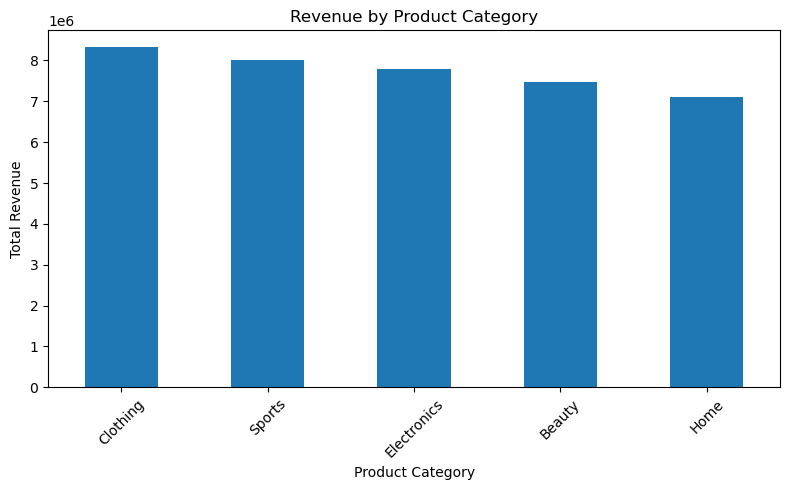

In [19]:
# Category-wise revenue chart

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# Calculate total spending per customer

customer_spending = df.groupby("Customer_ID")["Total_Amount"].sum()

customer_spending.head()

Customer_ID
1001    125405.31
1002     62406.45
1003     60571.49
1004     83075.92
1005    146249.62
Name: Total_Amount, dtype: float64

In [21]:
# Top 10 customers by total spending

top_customers = customer_spending.sort_values(
    ascending=False
).head(10)

print(top_customers)

Customer_ID
1313    180273.74
1288    169574.77
1111    161340.93
1476    161059.24
1260    159238.89
1147    155529.31
1198    154646.89
1277    154495.31
1344    152640.45
1264    152391.24
Name: Total_Amount, dtype: float64


In [22]:
# Find the latest transaction date

latest_date = df["Order_Date"].max()

print("Latest Transaction Date:", latest_date)

Latest Transaction Date: 2025-12-31 00:00:00


In [23]:
# Calculate Recency for each customer

recency = df.groupby("Customer_ID")["Order_Date"].max().reset_index()

recency["Recency"] = (
    latest_date - recency["Order_Date"]
).dt.days

recency.head()

,Customer_ID,Order_Date,Recency
0,1001,2025-12-21 22:42:30.750150032,9
1,1002,2025-11-01 06:34:38.335667136,59
2,1003,2025-07-02 18:39:58.079615920,181
3,1004,2025-09-11 17:57:02.844568912,110
4,1005,2025-12-05 21:11:29.177835568,25


In [24]:
# Calculate Frequency for each customer

frequency = df.groupby("Customer_ID").size().reset_index(
    name="Frequency"
)

frequency.head()

,Customer_ID,Frequency
0,1001,14
1,1002,10
2,1003,9
3,1004,10
4,1005,15


In [25]:
# Calculate total spending per customer

monetary = df.groupby("Customer_ID")["Total_Amount"].sum().reset_index(
    name="Total_Spending"
)

monetary.head()

,Customer_ID,Total_Spending
0,1001,125405.31
1,1002,62406.45
2,1003,60571.49
3,1004,83075.92
4,1005,146249.62


In [26]:
# Calculate Average Order Value (AOV)

aov = df.groupby("Customer_ID")["Total_Amount"].mean().reset_index(
    name="AOV"
)

aov.head()

,Customer_ID,AOV
0,1001,8957.522143
1,1002,6240.645000
2,1003,6730.165556
3,1004,8307.592000
4,1005,9749.974667


In [27]:
# Calculate total spending per customer

monetary = df.groupby("Customer_ID")["Total_Amount"].sum().reset_index(
    name="Total_Spending"
)

monetary.head()

,Customer_ID,Total_Spending
0,1001,125405.31
1,1002,62406.45
2,1003,60571.49
3,1004,83075.92
4,1005,146249.62


In [28]:
# Combine customer features

customer_features = recency[
    ["Customer_ID", "Recency"]
].merge(
    frequency,
    on="Customer_ID"
).merge(
    aov,
    on="Customer_ID"
).merge(
    monetary,
    on="Customer_ID"
)

customer_features.head()

,Customer_ID,Recency,Frequency,AOV,Total_Spending
0,1001,9,14,8957.522143,125405.31
1,1002,59,10,6240.645000,62406.45
2,1003,181,9,6730.165556,60571.49
3,1004,110,10,8307.592000,83075.92
4,1005,25,15,9749.974667,146249.62


In [29]:
print("Customer-level dataset shape:", customer_features.shape)

print("\nColumns:")
print(customer_features.columns)

Customer-level dataset shape: (500, 5)

Columns:
Index(['Customer_ID', 'Recency', 'Frequency', 'AOV', 'Total_Spending'], dtype='object')


In [30]:
customer_features.isnull().sum()

Customer_ID       0
Recency           0
Frequency         0
AOV               0
Total_Spending    0
dtype: int64

In [31]:
# Save customer-level features

customer_features.to_csv(
    "../output/customer_features.csv",
    index=False
)

print("Customer features saved successfully!")

Customer features saved successfully!


In [32]:
# Create LTV target

customer_features["LTV"] = customer_features["Total_Spending"]

# Display first 5 rows
customer_features.head()

,Customer_ID,Recency,Frequency,AOV,Total_Spending,LTV
0,1001,9,14,8957.522143,125405.31,125405.31
1,1002,59,10,6240.645000,62406.45,62406.45
2,1003,181,9,6730.165556,60571.49,60571.49
3,1004,110,10,8307.592000,83075.92,83075.92
4,1005,25,15,9749.974667,146249.62,146249.62


In [33]:
# Check LTV statistics

customer_features["LTV"].describe()

count       500.000000
mean      77362.031240
std       31805.363182
min        2568.040000
25%       53480.137500
50%       73662.290000
75%       97913.737500
max      180273.740000
Name: LTV, dtype: float64

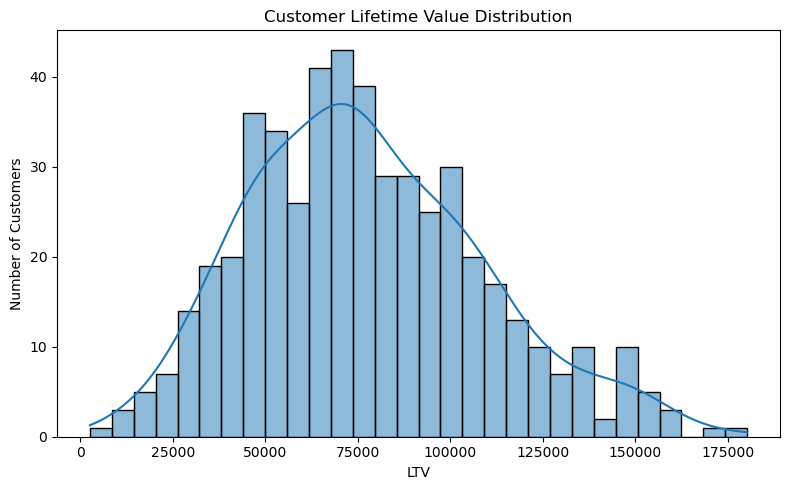

In [34]:
# LTV distribution

plt.figure(figsize=(8, 5))

sns.histplot(customer_features["LTV"], bins=30, kde=True)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("LTV")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [35]:
# Select numerical columns

correlation_data = customer_features[
    ["Recency", "Frequency", "AOV", "Total_Spending", "LTV"]
]

correlation_data.corr()

,Recency,Frequency,AOV,Total_Spending,LTV
Recency,1.000000,-0.318849,-0.049982,-0.283043,-0.283043
Frequency,-0.318849,1.000000,-0.029531,0.794596,0.794596
AOV,-0.049982,-0.029531,1.000000,0.538157,0.538157
Total_Spending,-0.283043,0.794596,0.538157,1.000000,1.000000
LTV,-0.283043,0.794596,0.538157,1.000000,1.000000


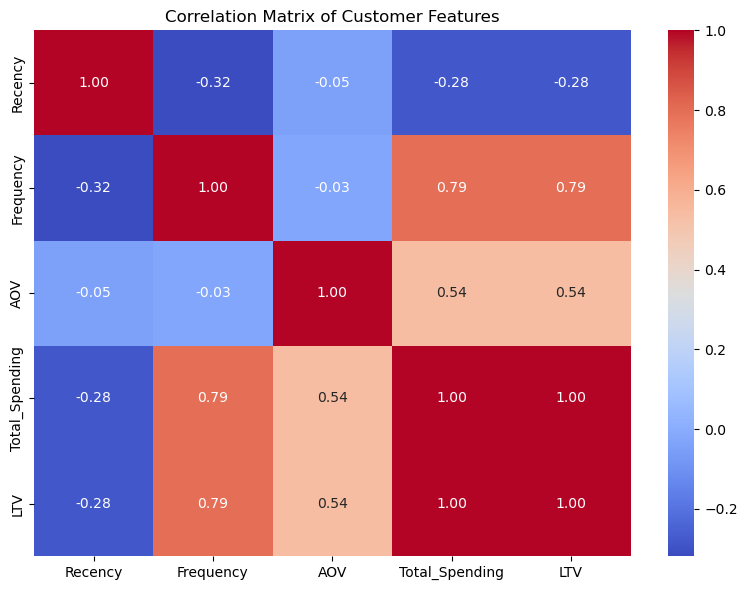

In [36]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Customer Features")

plt.tight_layout()
plt.show()

In [37]:
# Select input features

X = customer_features[
    ["Recency", "Frequency", "AOV"]
]

# Select target variable

y = customer_features["LTV"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Recency  Frequency          AOV
0        9         14  8957.522143
1       59         10  6240.645000
2      181          9  6730.165556
3      110         10  8307.592000
4       25         15  9749.974667

Target (y):
0    125405.31
1     62406.45
2     60571.49
3     83075.92
4    146249.62
Name: LTV, dtype: float64


In [38]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 3)
Testing data: (100, 3)


In [39]:
# Create Random Forest Regression model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [40]:
# Train the model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [41]:
# Predict LTV

y_pred = model.predict(X_test)

print("First 10 predicted LTV values:")
print(y_pred[:10])

First 10 predicted LTV values:
[ 27159.6287  36397.3003  96467.9779  46320.4803  50865.4747 102472.2422
  48215.4752  73626.03   105725.2231  88815.9216]


In [42]:
# Compare actual and predicted LTV

comparison = pd.DataFrame({
    "Actual_LTV": y_test.values,
    "Predicted_LTV": y_pred
})

comparison.head(10)

,Actual_LTV,Predicted_LTV
0,26136.89,27159.6287
1,36298.16,36397.3003
2,98248.30,96467.9779
3,46697.27,46320.4803
4,51479.91,50865.4747
5,101427.16,102472.2422
6,48639.87,48215.4752
7,73908.21,73626.0300
8,105169.46,105725.2231
9,84512.95,88815.9216


In [43]:
# Calculate Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))

Mean Absolute Error (MAE): 2629.06


In [44]:
# Calculate Root Mean Squared Error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Root Mean Squared Error (RMSE): 5594.23


In [45]:
print("===== MODEL PERFORMANCE =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))


===== MODEL PERFORMANCE =====
MAE : 2629.06
RMSE: 5594.23


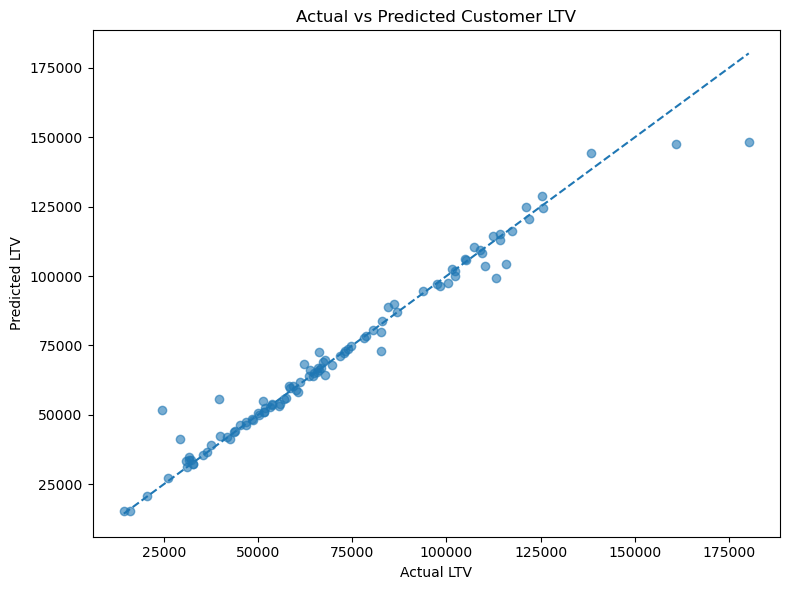

In [46]:
# Actual vs Predicted LTV

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Customer LTV")
plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")

plt.tight_layout()
plt.show()

In [47]:
# Get feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Frequency,0.627886
2,AOV,0.365095
0,Recency,0.007019


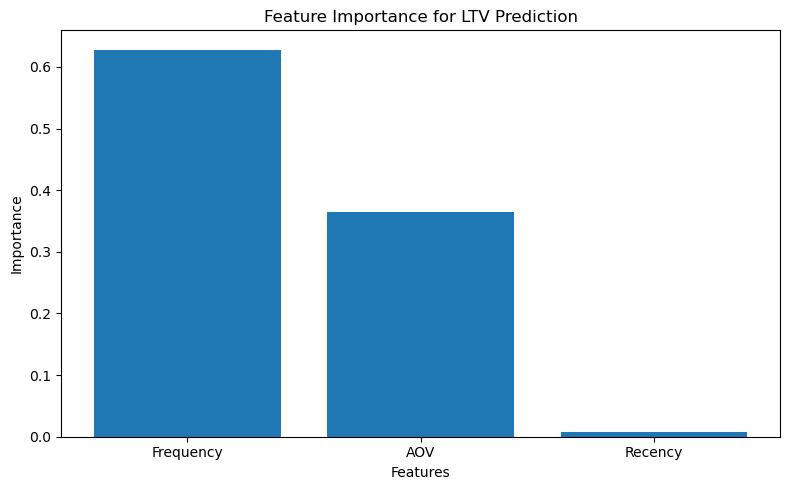

In [48]:
# Feature importance visualization

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance for LTV Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

In [49]:
# Save feature importance

feature_importance.to_csv(
    "../output/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [50]:
import joblib

joblib.dump(
    model,
    "../models/customer_ltv_random_forest.pkl"
)

print("Trained model saved successfully!")

Trained model saved successfully!


In [51]:
# prediction all the customer
all_predictions = model.predict(X)

customer_features["Predicted_LTV"] = all_predictions

customer_features.head()

,Customer_ID,Recency,Frequency,AOV,Total_Spending,LTV,Predicted_LTV
0,1001,9,14,8957.522143,125405.31,125405.31,128817.4467
1,1002,59,10,6240.645000,62406.45,62406.45,62307.7953
2,1003,181,9,6730.165556,60571.49,60571.49,58018.9267
3,1004,110,10,8307.592000,83075.92,83075.92,82805.1962
4,1005,25,15,9749.974667,146249.62,146249.62,146244.1771


In [52]:
# Create Final LTV Prediction File
final_predictions = customer_features[
    ["Customer_ID", "Recency", "Frequency", "AOV", "LTV", "Predicted_LTV"]
]

final_predictions.head(10)

,Customer_ID,Recency,Frequency,AOV,LTV,Predicted_LTV
0,1001,9,14,8957.522143,125405.31,128817.4467
1,1002,59,10,6240.645000,62406.45,62307.7953
2,1003,181,9,6730.165556,60571.49,58018.9267
3,1004,110,10,8307.592000,83075.92,82805.1962
4,1005,25,15,9749.974667,146249.62,146244.1771
5,1006,538,4,6934.862500,27739.45,29310.9781
6,1007,49,11,9112.196364,100234.16,101016.6303
7,1008,28,14,7012.251429,98171.52,97457.3926
8,1009,287,9,6362.512222,57262.61,56247.8542
9,1010,191,9,3500.871111,31507.84,33634.3651


In [53]:
# Save the Final LTV Prediction CSV
final_predictions.to_csv(
    "../output/final_ltv_predictions.csv",
    index=False
)

print("Final LTV prediction file saved successfully!")

Final LTV prediction file saved successfully!


In [54]:
# Check predicted LTV values
print("Minimum Predicted LTV:", round(final_predictions["Predicted_LTV"].min(), 2))
print("Maximum Predicted LTV:", round(final_predictions["Predicted_LTV"].max(), 2))
print("Average Predicted LTV:", round(final_predictions["Predicted_LTV"].mean(), 2))

Minimum Predicted LTV: 5815.35
Maximum Predicted LTV: 160814.02
Average Predicted LTV: 77351.41


In [55]:
# Create Customer Segments
low_limit = final_predictions["Predicted_LTV"].quantile(0.33)
high_limit = final_predictions["Predicted_LTV"].quantile(0.66)

def assign_segment(ltv):
    if ltv >= high_limit:
        return "High LTV"
    elif ltv >= low_limit:
        return "Medium LTV"
    else:
        return "Low LTV"

final_predictions["Customer_Segment"] = (
    final_predictions["Predicted_LTV"].apply(assign_segment)
)

final_predictions.head(10)

,Customer_ID,Recency,Frequency,AOV,LTV,Predicted_LTV,Customer_Segment
0,1001,9,14,8957.522143,125405.31,128817.4467,High LTV
1,1002,59,10,6240.645000,62406.45,62307.7953,Medium LTV
2,1003,181,9,6730.165556,60571.49,58018.9267,Low LTV
3,1004,110,10,8307.592000,83075.92,82805.1962,Medium LTV
4,1005,25,15,9749.974667,146249.62,146244.1771,High LTV
5,1006,538,4,6934.862500,27739.45,29310.9781,Low LTV
6,1007,49,11,9112.196364,100234.16,101016.6303,High LTV
7,1008,28,14,7012.251429,98171.52,97457.3926,High LTV
8,1009,287,9,6362.512222,57262.61,56247.8542,Low LTV
9,1010,191,9,3500.871111,31507.84,33634.3651,Low LTV


In [56]:
# Check Customer Segments
segment_counts = final_predictions["Customer_Segment"].value_counts()

print("Customer Segmentation:")
print(segment_counts)

Customer Segmentation:
Customer_Segment
High LTV      170
Medium LTV    165
Low LTV       165
Name: count, dtype: int64


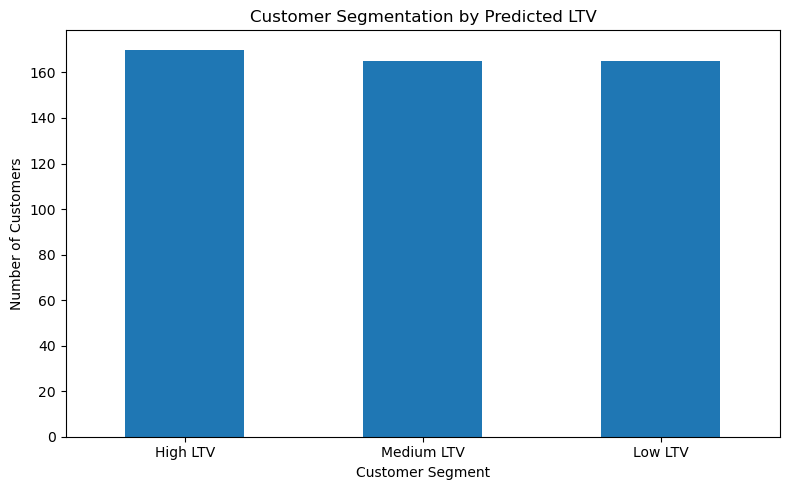

In [57]:
# Visualize Customer Segments
plt.figure(figsize=(8, 5))

segment_counts.plot(kind="bar")

plt.title("Customer Segmentation by Predicted LTV")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [58]:
# Save Customer Segmentation
final_predictions.to_csv(
    "../output/customer_ltv_segmentation.csv",
    index=False
)

print("Customer LTV segmentation file saved successfully!")

Customer LTV segmentation file saved successfully!


In [59]:
# Save the Final Updated Prediction File
final_predictions.to_csv(
    "../output/final_ltv_predictions.csv",
    index=False
)

print("Final LTV prediction file updated successfully!")

Final LTV prediction file updated successfully!


In [60]:
# check  final output
print("Final Dataset Shape:", final_predictions.shape)

print("\nColumns:")
print(final_predictions.columns.tolist())

print("\nFirst 10 Records:")
final_predictions.head(10)

Final Dataset Shape: (500, 7)

Columns:
['Customer_ID', 'Recency', 'Frequency', 'AOV', 'LTV', 'Predicted_LTV', 'Customer_Segment']

First 10 Records:


,Customer_ID,Recency,Frequency,AOV,LTV,Predicted_LTV,Customer_Segment
0,1001,9,14,8957.522143,125405.31,128817.4467,High LTV
1,1002,59,10,6240.645000,62406.45,62307.7953,Medium LTV
2,1003,181,9,6730.165556,60571.49,58018.9267,Low LTV
3,1004,110,10,8307.592000,83075.92,82805.1962,Medium LTV
4,1005,25,15,9749.974667,146249.62,146244.1771,High LTV
5,1006,538,4,6934.862500,27739.45,29310.9781,Low LTV
6,1007,49,11,9112.196364,100234.16,101016.6303,High LTV
7,1008,28,14,7012.251429,98171.52,97457.3926,High LTV
8,1009,287,9,6362.512222,57262.61,56247.8542,Low LTV
9,1010,191,9,3500.871111,31507.84,33634.3651,Low LTV


In [61]:
# Save the Customer Segment Summary
segment_summary = (
    final_predictions["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Customer_Segment", "Customer_Count"]

segment_summary

,Customer_Segment,Customer_Count
0,High LTV,170
1,Medium LTV,165
2,Low LTV,165


In [62]:
segment_summary.to_csv(
    "../output/customer_segment_summary.csv",
    index=False
)

print("Customer segment summary saved successfully!")

Customer segment summary saved successfully!


In [63]:
# Create LTV Segment Revenue Summary
segment_ltv_summary = (
    final_predictions
    .groupby("Customer_Segment")["Predicted_LTV"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

segment_ltv_summary

,count,mean,min,max
Customer_Segment,,,,
High LTV,170,112142.91,88164.35,160814.02
Low LTV,165,44649.64,5815.35,61716.47
Medium LTV,165,74207.40,61789.31,87870.97


In [64]:
segment_ltv_summary.to_csv(
    "../output/segment_ltv_summary.csv"
)

print("Segment LTV summary saved successfully!")

Segment LTV summary saved successfully!


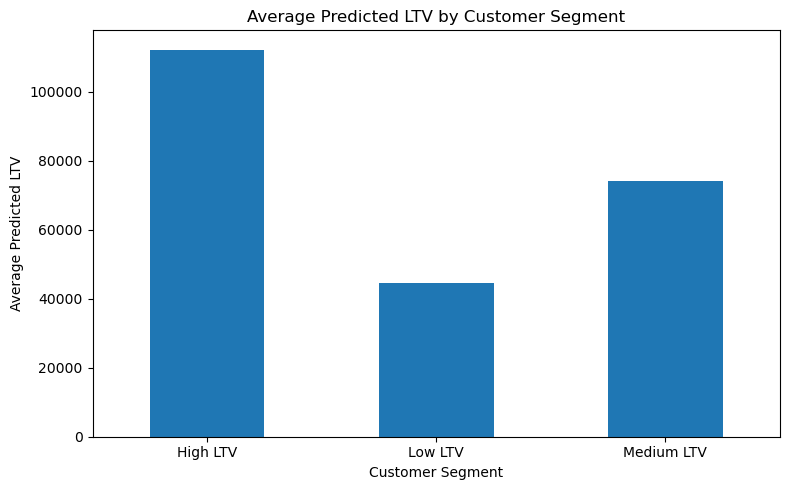

In [65]:
# Create One Final Visualization
plt.figure(figsize=(8, 5))

segment_ltv_summary["mean"].plot(kind="bar")

plt.title("Average Predicted LTV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Predicted LTV")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

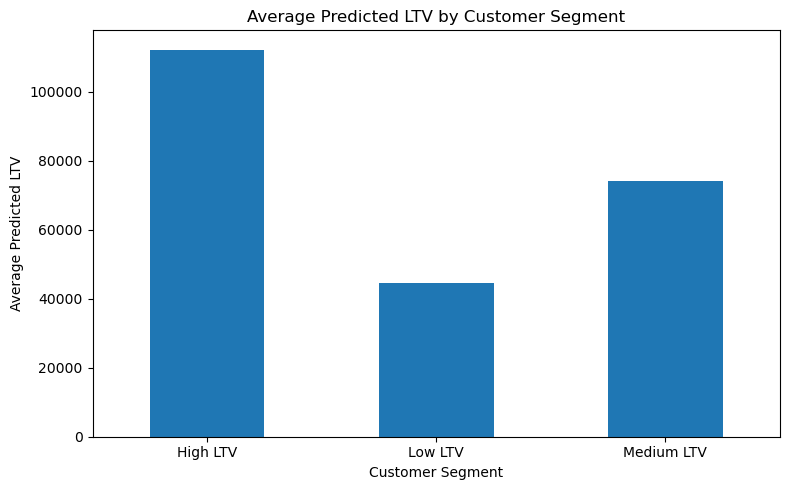

Visualization saved successfully!


In [66]:
# visualizations
plt.figure(figsize=(8, 5))

segment_ltv_summary["mean"].plot(kind="bar")

plt.title("Average Predicted LTV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Predicted LTV")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/average_ltv_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization saved successfully!")

In [67]:
model_performance = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Value": [mae, rmse]
})

model_performance
model_performance.to_csv(
    "../output/model_performance.csv",
    index=False
)

print("Model performance saved successfully!")

Model performance saved successfully!


In [68]:
import os
# check the result
print("===== OUTPUT FILES =====")
for file in os.listdir("../output"):
    print(file)

print("\n===== MODEL FILES =====")
for file in os.listdir("../models"):
    print(file)

print("\n===== VISUALIZATION FILES =====")
for file in os.listdir("../visualizations"):
    print(file)

===== OUTPUT FILES =====
customer_features.csv
customer_ltv_segmentation.csv
customer_segment_summary.csv
feature_importance.csv
final_ltv_predictions.csv
model_performance.csv
segment_ltv_summary.csv

===== MODEL FILES =====
customer_ltv_random_forest.pkl

===== VISUALIZATION FILES =====
average_ltv_by_segment.png
